Heatmap successfully generated!


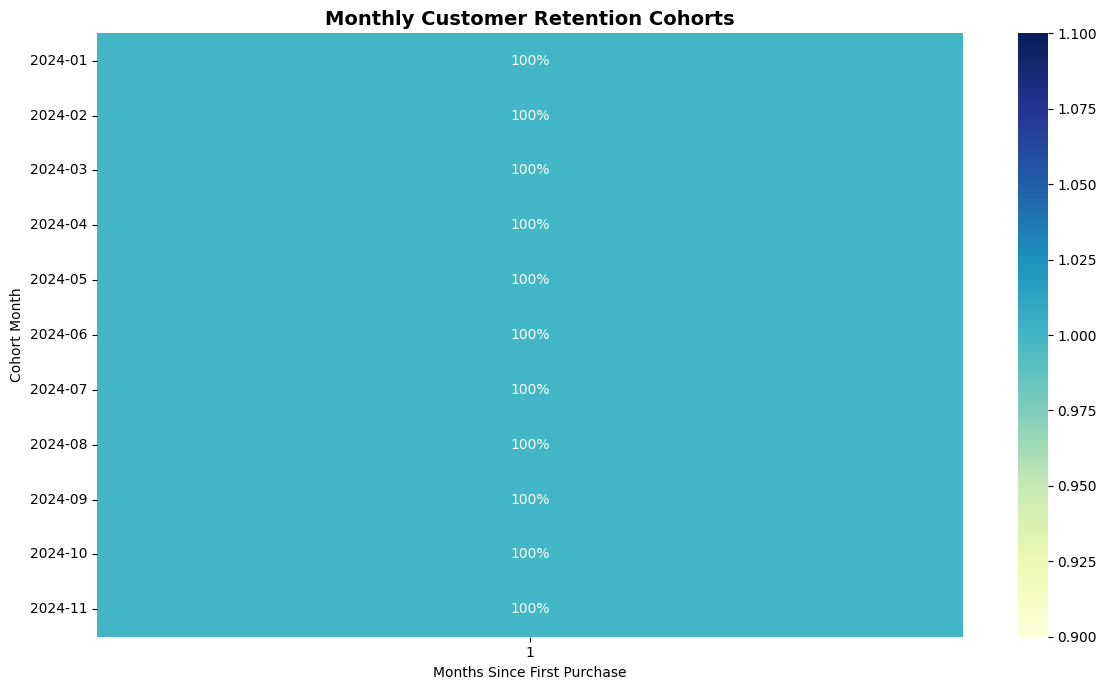

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv('ecommerce_dataset_updated.csv')
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], dayfirst=True)

# 2. Assign transaction month and cohort month
df['InvoiceMonth'] = df['Purchase_Date'].dt.to_period('M')
df['CohortMonth'] = df.groupby('User_ID')['Purchase_Date'].transform('min').dt.to_period('M')

# 3. Calculate cohort index (months elapsed)
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n) + 1

# 4. Build cohort pivot table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['User_ID'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='User_ID')

# 5. Compute retention percentage
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

# 6. Generate and save heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Customer Retention Cohorts', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=300)
print("Heatmap successfully generated!")